In [55]:
from driver_model import driver_model
import pandas as pd
from database import database
from matplotlib import pyplot as pt

data = database()
driver_id = data.getDrivers().query(
    "driverRef == 'hamilton'"
)["driverId"].iloc[0]

result_records = data.getResults().query(
    "driverId == @driver_id"
)
qualifying_records = data.getQualifying().query(
    "driverId == @driver_id"
)[["raceId", "driverId", "position", "q1", "q2", "q3"]].rename(
    columns={"position": "qualifying_position"}
)
race_records = data.getRaces().merge(
    data.getCircuits()[["circuitId"]],
    on="circuitId"
)

training_data = race_records.merge(
    result_records,
    on="raceId",
    suffixes=("_race", "_result")
).merge(
    qualifying_records,
    on=["raceId", "driverId"],
    how="left"
).sort_values("date")

qualifying_time_columns = ["q1", "q2", "q3"]

def lap_time_to_seconds(value):
    if pd.isna(value) or value == "\\N":
        return 0
    minutes, seconds = str(value).split(":")
    return int(minutes) * 60 + float(seconds)

for column in qualifying_time_columns:
    training_data[column] = training_data[column].apply(lap_time_to_seconds)


output hamilton race results 

In [ ]:
training_data

convert to numpy vector

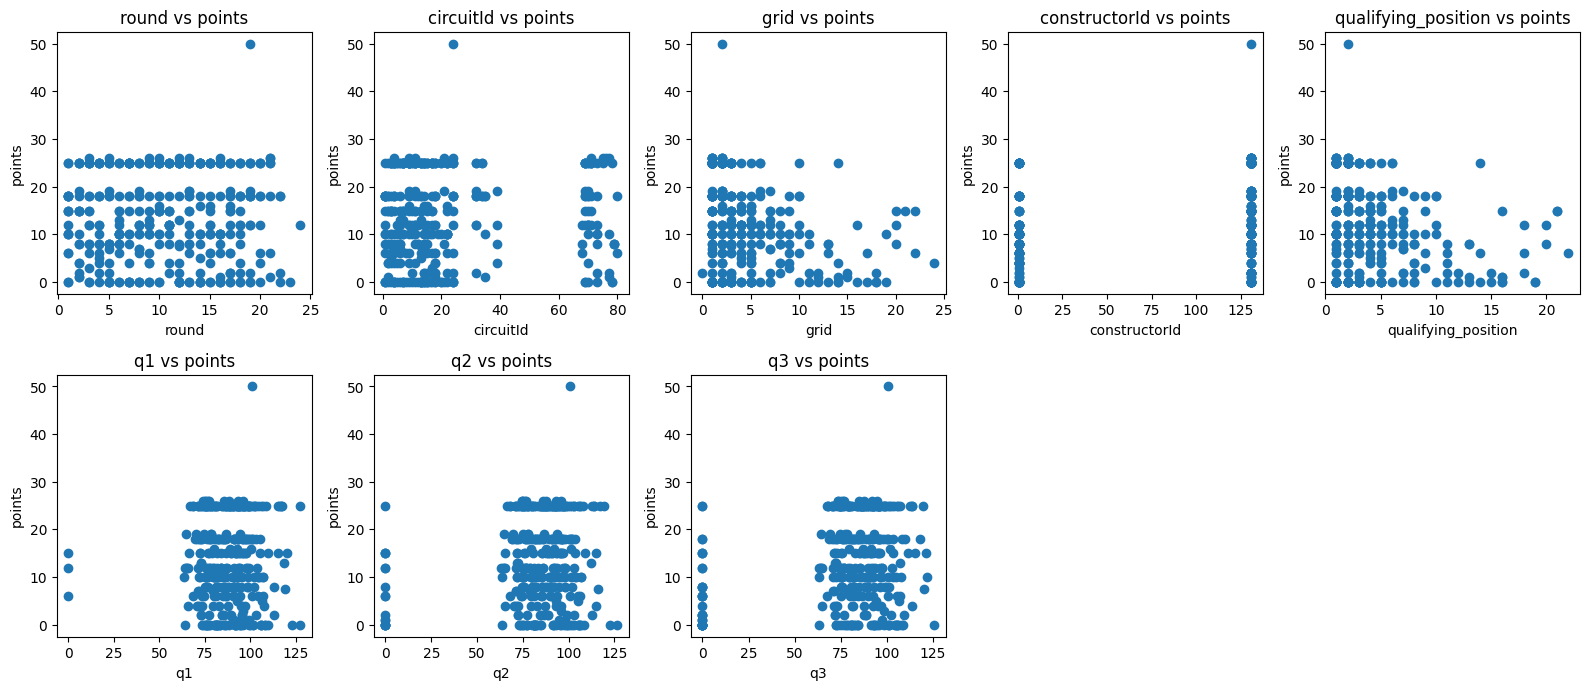

In [56]:

feature_columns = [
    "round",
    "circuitId",
    "grid",
    "constructorId",
    "qualifying_position",
    "q1",
    "q2",
    "q3"
]

X = (
    training_data[feature_columns]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .to_numpy()
)
y = training_data["points"].to_numpy()


figure, axes = pt.subplots(3, 5, figsize=(16, 10))
for index, feature_name in enumerate(feature_columns):
    axis = axes.flat[index]
    axis.scatter(X[:, index], y)
    axis.set_xlabel(feature_name)
    axis.set_ylabel("points")
    axis.set_title(f"{feature_name} vs points")

for axis in axes.flat[len(feature_columns):]:
    axis.set_visible(False)

figure.tight_layout()
pt.show()

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = driver_model(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Train MAE:", train_mae)
print("Test MAE:", test_mae)
print("Test R2 score:", r2_score(y_test, y_test_pred))

Training rows: 284
Testing rows: 72
Train MAE: 5.8725016879833
Test MAE: 6.691119245251339
Test R2 score: 0.3079976953677428
